# Player Clustering Notebook

This notebook loads the processed player dataset and applies KMeans clustering to categorize players based on batting style, bowling style, and fielding position. After clustering, it reduces features to 2D using PCA and plots the resulting player clusters.

In [12]:
import pandas as pd
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')
p = Path('data/raw_data/players-data-updated.csv')
print('exists', p.exists())
if p.exists():
    df = pd.read_csv(p, encoding='latin1')
    print('shape', df.shape)
    print(df.columns.tolist())
    print(df.head(5).to_string(index=False))

exists False


In [8]:
import sys
print(sys.executable)
!"{sys.executable}" -m pip install pandas numpy matplotlib seaborn scikit-learn

C:\Users\DELL\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\DELL\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


load data

In [9]:
from pathlib import Path

candidate_paths = [
    Path("..") / "data" / "processed_data" / "clean_players.csv",
    Path.cwd() / "StratPlay-Intelligence" / "data" / "processed_data" / "clean_players.csv",
]

for p in candidate_paths:
    if p.exists():
        data_path = p
        break
else:
    raise FileNotFoundError("clean_players.csv not found in expected locations")

print("Loading players from:", data_path)
df_players = pd.read_csv(data_path)
df_players.head()

Loading players from: ..\data\processed_data\clean_players.csv


,player_id,player_name,bat_style,bowl_style,field_pos,player_full_name,player_name2,player_image
0,6730,Mohsin Khan,Left hand Bat,Left arm Medium fast,NaN,Mohsin Khan,Mohsin Khan,NaN
1,22,Rashid Khan,Right hand Bat,Legbreak Googly,,Rashid Khan Arman,Rashid Khan,https://www.espncricinfo.com/cricketers/rashid...
2,590,K Rabada,Left hand Bat,Right arm Fast,,Kagiso Rabada,Kagiso Rabada,https://ipl-stats-sports-mechanic.s3.ap-south-...
3,1424,SN Khan,Right hand Bat,Legbreak,,Sarfaraz Naushad Khan,Sarfaraz Naushad,NaN
4,963,MN Samuels,Right hand Bat,Right arm Offbreak,,Marlon Nathaniel Samuels,Marlon Nathaniel,NaN


In [13]:
# Yeh IPL ke typical columns hain — apne actual columns se match karo
features = ['runs', 'wickets', 'matches', 'strike_rate', 'economy', 'average']

# Sirf woh columns lo jo exist karte hain
features = [f for f in features if f in df.columns]
print("Using features:", features)

player_names = df['player_name']  # ← column name apna check karo
X = df[features].fillna(0)

NameError: name 'df' is not defined

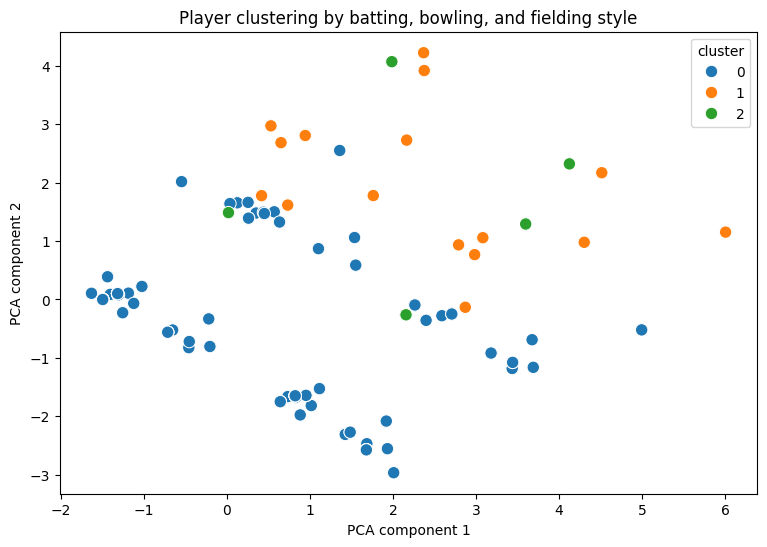

,cluster_size,sample_players
cluster,,
0,665,"Mohsin Khan, Rashid Khan, K Rabada, SN Khan, M..."
1,53,"TM Head, CA Ingram, MS Wade, H Klaasen, Sameer..."
2,54,"SS Tiwary, JJ Roy, Vishnu Vinod, Ishan Kishan,..."


In [10]:
feature_cols = ["bat_style", "bowl_style", "field_pos"]
player_features = df_players[feature_cols].fillna("Unknown")
player_encoded = pd.get_dummies(player_features, prefix=["bat", "bowl", "field"])

scaler = StandardScaler()
X = scaler.fit_transform(player_encoded)

kmeans = KMeans(n_clusters=3, random_state=42)
df_players["cluster"] = kmeans.fit_predict(X)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)
df_players["pca_1"] = coords[:, 0]
df_players["pca_2"] = coords[:, 1]

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_players, x="pca_1", y="pca_2", hue="cluster", palette="tab10", s=80)
plt.title("Player clustering by batting, bowling, and fielding style")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.legend(title="cluster")
plt.show()

cluster_summary = df_players.groupby("cluster").agg(cluster_size=("player_id", "count"))
cluster_summary["sample_players"] = df_players.groupby("cluster")["player_name"].apply(lambda names: ", ".join(names.head(5)))
cluster_summary

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [17]:
# Raw Data
players_raw = pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\internship_project\StratPlay-Intelligence\data\raw_data\players-data-updated.csv", encoding='latin1')
ball_by_ball  = pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\internship_project\StratPlay-Intelligence\data\raw_data\ball_by_ball_data.csv", encoding='latin1')
matches       = pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\internship_project\StratPlay-Intelligence\data\raw_data\ipl_matches_data.csv", encoding='latin1')

# Processed Data
players_clean = pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\internship_project\StratPlay-Intelligence\data\processed_data\clean_players.csv", encoding='latin1')
deliveries    = pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\internship_project\StratPlay-Intelligence\data\processed_data\clean_deliveries.csv", encoding='latin1')

print("Players Raw shape:", players_raw.shape)
print("Ball by Ball shape:", ball_by_ball.shape)
print("\n📋 Players columns:", players_raw.columns.tolist())
print("\n📋 Ball by Ball columns:", ball_by_ball.columns.tolist())

Players Raw shape: (772, 8)
Ball by Ball shape: (278205, 30)

📋 Players columns: ['player_id', 'player_name', 'bat_style', 'bowl_style', 'field_pos', 'player_full_name', 'player_name2', 'player_image']

📋 Ball by Ball columns: ['season_id', 'match_id', 'batter', 'bowler', 'non_striker', 'team_batting', 'team_bowling', 'over_number', 'ball_number', 'batter_runs', 'extras', 'total_runs', 'batsman_type', 'bowler_type', 'player_out', 'fielders_involved', 'is_wicket', 'is_wide_ball', 'is_no_ball', 'is_leg_bye', 'is_bye', 'is_penalty', 'wide_ball_runs', 'no_ball_runs', 'leg_bye_runs', 'bye_runs', 'penalty_runs', 'wicket_kind', 'is_super_over', 'innings']


In [18]:
print("=== PLAYERS RAW ===")
print(players_raw.head(3))
print("\n=== BALL BY BALL (first 3 rows) ===")
print(ball_by_ball.head(3))

=== PLAYERS RAW ===
   player_id  player_name       bat_style            bowl_style field_pos  \
0       6730  Mohsin Khan   Left hand Bat  Left arm Medium fast       NaN   
1         22  Rashid Khan  Right hand Bat       Legbreak Googly             
2        590     K Rabada   Left hand Bat        Right arm Fast             

    player_full_name   player_name2  \
0        Mohsin Khan    Mohsin Khan   
1  Rashid Khan Arman    Rashid Khan   
2      Kagiso Rabada  Kagiso Rabada   

                                        player_image  
0                                                NaN  
1  https://www.espncricinfo.com/cricketers/rashid...  
2  https://ipl-stats-sports-mechanic.s3.ap-south-...  

=== BALL BY BALL (first 3 rows) ===
   season_id  match_id       batter   bowler  non_striker  \
0       2008    335982   SC Ganguly  P Kumar  BB McCullum   
1       2008    335982  BB McCullum  P Kumar   SC Ganguly   
2       2008    335982  BB McCullum  P Kumar   SC Ganguly   

            

In [26]:
# --- BATTING STATS ---
batting = ball_by_ball.groupby('batter').agg(
    total_runs    = ('batter_runs', 'sum'),
    balls_faced   = ('batter_runs', 'count'),
    dismissals    = ('player_out', lambda x: x.notna().sum())
).reset_index()

batting['strike_rate']    = (batting['total_runs'] / batting['balls_faced'] * 100).round(2)
batting['batting_avg']    = (batting['total_runs'] / batting['dismissals'].replace(0, 1)).round(2)
batting.rename(columns={'batter': 'player_name'}, inplace=True)

print("✅ Batting stats:", batting.shape)
batting.head()

✅ Batting stats: (703, 6)


,player_name,total_runs,balls_faced,dismissals,strike_rate,batting_avg
0,A Ashish Reddy,280,196,15,142.86,18.67
1,A Badoni,963,740,36,130.14,26.75
2,A Chandila,4,7,1,57.14,4.00
3,A Chopra,53,75,5,70.67,10.60
4,A Choudhary,25,20,2,125.00,12.50


In [21]:
print("Ball by Ball Columns:")
print(ball_by_ball.columns.tolist())
print("\nFirst 3 rows:")
print(ball_by_ball.head(3))
print("\nData types:")
print(ball_by_ball.dtypes)

Ball by Ball Columns:
['season_id', 'match_id', 'batter', 'bowler', 'non_striker', 'team_batting', 'team_bowling', 'over_number', 'ball_number', 'batter_runs', 'extras', 'total_runs', 'batsman_type', 'bowler_type', 'player_out', 'fielders_involved', 'is_wicket', 'is_wide_ball', 'is_no_ball', 'is_leg_bye', 'is_bye', 'is_penalty', 'wide_ball_runs', 'no_ball_runs', 'leg_bye_runs', 'bye_runs', 'penalty_runs', 'wicket_kind', 'is_super_over', 'innings']

First 3 rows:
   season_id  match_id       batter   bowler  non_striker  \
0       2008    335982   SC Ganguly  P Kumar  BB McCullum   
1       2008    335982  BB McCullum  P Kumar   SC Ganguly   
2       2008    335982  BB McCullum  P Kumar   SC Ganguly   

            team_batting                 team_bowling  over_number  \
0  Kolkata Knight Riders  Royal Challengers Bangalore            0   
1  Kolkata Knight Riders  Royal Challengers Bangalore            0   
2  Kolkata Knight Riders  Royal Challengers Bangalore            0   

   ball

In [28]:
# --- BOWLING STATS ---
bowling = ball_by_ball.groupby('bowler').agg(
    wickets       = ('player_out', lambda x: x.notna().sum()),
    balls_bowled  = ('ball_number', 'count'),
    runs_conceded = ('total_runs', 'sum')
).reset_index()

bowling['overs_bowled'] = (bowling['balls_bowled'] / 6).round(2)
bowling['economy']      = (bowling['runs_conceded'] / bowling['overs_bowled'].replace(0, 1)).round(2)
bowling['bowling_avg']  = (bowling['runs_conceded'] / bowling['wickets'].replace(0, 1)).round(2)
bowling.rename(columns={'bowler': 'player_name'}, inplace=True)

print("✅ Bowling stats:", bowling.shape)
bowling.head()

✅ Bowling stats: (550, 7)


,player_name,wickets,balls_bowled,runs_conceded,overs_bowled,economy,bowling_avg
0,A Ashish Reddy,19,270,400,45.00,8.89,21.05
1,A Badoni,4,35,50,5.83,8.58,12.50
2,A Chandila,11,234,245,39.00,6.28,22.27
3,A Choudhary,5,108,144,18.00,8.00,28.80
4,A Dananjaya,0,25,47,4.17,11.27,47.00


In [29]:
# Batting + Bowling merge
player_stats = pd.merge(batting, bowling, on='player_name', how='outer').fillna(0)

# Matches played count
matches_played = ball_by_ball.groupby('batter')['match_id'].nunique().reset_index()
matches_played.columns = ['player_name', 'matches_played']
player_stats = pd.merge(player_stats, matches_played, on='player_name', how='left').fillna(0)

print("✅ Master player stats shape:", player_stats.shape)
print(player_stats.head())

✅ Master player stats shape: (767, 13)
      player_name  total_runs  balls_faced  dismissals  strike_rate  \
0  A Ashish Reddy       280.0        196.0        15.0       142.86   
1        A Badoni       963.0        740.0        36.0       130.14   
2      A Chandila         4.0          7.0         1.0        57.14   
3        A Chopra        53.0         75.0         5.0        70.67   
4     A Choudhary        25.0         20.0         2.0       125.00   

   batting_avg  wickets  balls_bowled  runs_conceded  overs_bowled  economy  \
0        18.67     19.0         270.0          400.0         45.00     8.89   
1        26.75      4.0          35.0           50.0          5.83     8.58   
2         4.00     11.0         234.0          245.0         39.00     6.28   
3        10.60      0.0           0.0            0.0          0.00     0.00   
4        12.50      5.0         108.0          144.0         18.00     8.00   

   bowling_avg  matches_played  
0        21.05            

In [30]:
# Sirf woh players jo kam se kam 5 matches khele hain
player_stats = player_stats[player_stats['matches_played'] >= 5].copy()
player_stats = player_stats[player_stats['total_runs'] + player_stats['wickets'] > 0]

print(f"✅ Players for clustering: {len(player_stats)}")
player_stats.reset_index(drop=True, inplace=True)

✅ Players for clustering: 462


In [31]:
features = ['total_runs', 'strike_rate', 'batting_avg',
            'wickets', 'economy', 'bowling_avg', 'matches_played']

X = player_stats[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Data scaled. Shape:", X_scaled.shape)

✅ Data scaled. Shape: (462, 7)


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\DELL\\OneDrive\\Desktop\\internship_project\\StratPlay-Intelligence\\Final Dashboard\\images\\elbow_plot.png'

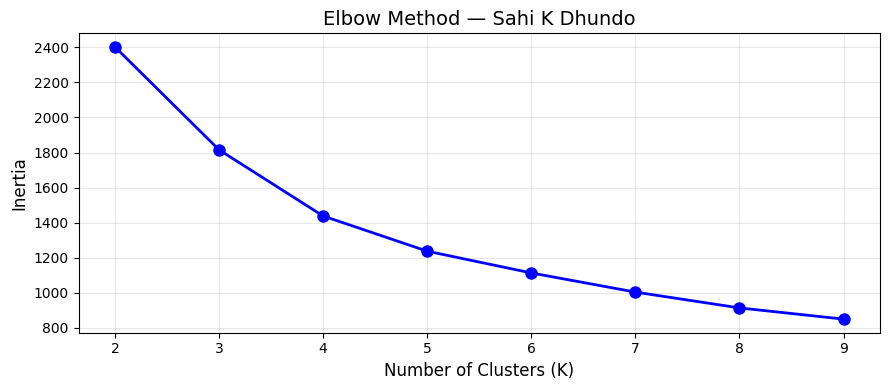

In [ ]:
inertia = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(9, 4))
plt.plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.title('Elbow Method — Sahi K Dhundo', fontsize=14)
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Create directory if it doesn't exist
from pathlib import Path
save_dir = Path(r"C:\Users\DELL\OneDrive\Desktop\internship_project\StratPlay-Intelligence\Final Dashboard\images")
save_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(save_dir / "elbow_plot.png", dpi=150)
plt.show()
print("👆 Jahan bend aaye (kohni jaisi shape) — woh K choose karo")